## Preparação

In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Suprime alertas para garantir a limpeza e apresentação profissional do notebook
warnings.filterwarnings("ignore")

In [2]:
# Identidade visual baseada nas cores do logo da Serasa Experian
SERASA_COLORS = {
    "azul": "#1D4F91",
    "pink": "#E80070",
    "roxo": "#77127B",
    "cinza_escuro": "#2D3748",
    "cinza_claro": "#F7FAFC",
}

In [3]:
# Configuração global de estilo dos gráficos
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 11,
        "axes.edgecolor": "none",
        "axes.facecolor": "white",
        "figure.facecolor": "white",
    }
)


def apply_chart_style(ax, title):
    """Aplica o padrão visual: eliminando ruídos visuais."""
    ax.set_title(
        title,
        fontsize=14,
        pad=20,
        fontweight="bold",
        color=SERASA_COLORS["cinza_escuro"],
        loc="center",
    )
    ax.grid(False)
    sns.despine(top=True, right=True, left=True, bottom=False)
    ax.yaxis.set_visible(False)
    ax.set_xlabel("")

## Entendimento do dataset

In [4]:
# Carregamento do dataset
df = pd.read_csv("../fraud_data.csv")

In [5]:
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,04-01-2019 00:58,"""Stokes, Christiansen and Sipes""",grocery_net,14.37,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a3806e984cec6ac0096d8184c64ad3a1,65.654142,-164.722603,1
1,04-01-2019 15:06,Predovic Inc,shopping_net,966.11,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a59185fe1b9ccf21323f581d7477573f,65.468863,-165.473127,1
2,04-01-2019 22:37,Wisozk and Sons,misc_pos,49.61,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,86ba3a888b42cd3925881fa34177b4e0,65.347667,-165.914542,1
3,04-01-2019 23:06,Murray-Smitham,grocery_pos,295.26,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,3a068fe1d856f0ecedbed33e4b5f4496,64.445035,-166.080207,1
4,04-01-2019 23:59,Friesen Lt,health_fitness,18.17,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,891cdd1191028759dc20dc224347a0ff,65.447094,-165.446843,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14446 entries, 0 to 14445
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  14446 non-null  str    
 1   merchant               14446 non-null  str    
 2   category               14446 non-null  str    
 3   amt                    14446 non-null  float64
 4   city                   14446 non-null  str    
 5   state                  14446 non-null  str    
 6   lat                    14446 non-null  float64
 7   long                   14446 non-null  float64
 8   city_pop               14446 non-null  int64  
 9   job                    14446 non-null  str    
 10  dob                    14446 non-null  str    
 11  trans_num              14446 non-null  str    
 12  merch_lat              14446 non-null  float64
 13  merch_long             14446 non-null  float64
 14  is_fraud               14446 non-null  str    
dtypes: float64(5)

In [7]:
df.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'city', 'state',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='str')

In [8]:
# Limpeza e adequação dos tipos de dados
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], dayfirst=True, errors="coerce")
df["dob"] = pd.to_datetime(df["dob"], dayfirst=True, errors="coerce")

In [9]:
# Garante target binário limpo (0 = Legítima, 1 = Fraude)
df["is_fraud"] = df["is_fraud"].astype(str).str.extract(r"(\d)").astype(int)

In [10]:
# Remove duplicatas para evitar distorção financeira
duplicados_iniciais = df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [11]:
# Tabela de validação da estrutura inicial
summary_table = pd.DataFrame(
    {
        "Métrica": [
            "Total de Registros",
            "Total de Colunas",
            "Valores Nulos",
            "Duplicatas Removidas",
        ],
        "Valor": [
            len(df) + duplicados_iniciais,
            df.shape[1],
            df.isnull().sum().sum(),
            duplicados_iniciais,
        ],
    }
)

In [12]:
print("--- TABELA 1: RESUMO DOS DADOS ---")
display(summary_table)

--- TABELA 1: RESUMO DOS DADOS ---


,Métrica,Valor
0,Total de Registros,14446
1,Total de Colunas,15
2,Valores Nulos,0
3,Duplicatas Removidas,63


## Distribuição de fraudes

In [13]:
# Distribuição de frequência e proporção
fraud_dist = (
    df["is_fraud"]
    .value_counts(normalize=True)
    .reset_index()
    .rename(columns={"is_fraud": "Classe", "proportion": "Proporção (%)"})
)

# Formata os valores para exibição na tabela e no gráfico
fraud_dist["Classe_Nome"] = fraud_dist["Classe"].map({0: "Legítima", 1: "Fraude"})
fraud_dist["Qtd_Transacoes"] = df["is_fraud"].value_counts().values
fraud_dist["Proporção (%)"] = (fraud_dist["Proporção (%)"] * 100).round(2)
fraud_dist["Proporção (%)"] = fraud_dist["Proporção (%)"].map("{:.2f}%".format)

In [14]:
print("--- TABELA 2: DISTRIBUIÇÃO DAS TRANSAÇÕES ---")
display(fraud_dist[["Classe_Nome", "Qtd_Transacoes", "Proporção (%)"]].style.hide())

--- TABELA 2: DISTRIBUIÇÃO DAS TRANSAÇÕES ---


Classe_Nome,Qtd_Transacoes,Proporção (%)
Legítima,12601,87.61%
Fraude,1782,12.39%


### Visualização de rosca com distribuição das transações

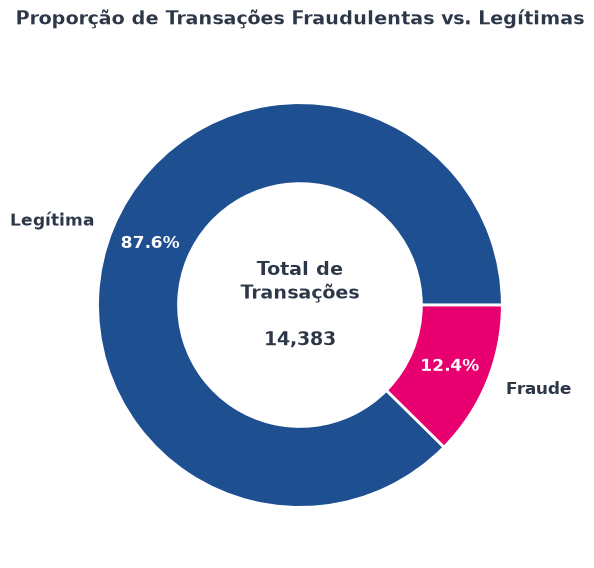

In [15]:
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(aspect="equal"))

valores = [fraud_dist.loc[0, "Qtd_Transacoes"], fraud_dist.loc[1, "Qtd_Transacoes"]]
labels = [fraud_dist.loc[0, "Classe_Nome"], fraud_dist.loc[1, "Classe_Nome"]]
cores = [SERASA_COLORS["azul"], SERASA_COLORS["pink"]]

wedges, texts, autotexts = ax.pie(
    valores,
    labels=labels,
    colors=cores,
    autopct="%1.1f%%",
    startangle=0,
    pctdistance=0.80,
    textprops=dict(color=SERASA_COLORS["cinza_escuro"], fontweight="bold", fontsize=12),
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2),
)

# Proporção
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(12)

# Total de transações
total_transacoes = sum(valores)
ax.text(
    0, 0,
    f"Total de\nTransações\n\n{total_transacoes:,.0f}",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    color=SERASA_COLORS["cinza_escuro"],
)

apply_chart_style(ax, "Proporção de Transações Fraudulentas vs. Legítimas")
ax.axis("off")

plt.tight_layout()
plt.show()

## Padrões temporais e de valor

In [16]:
# Estatística de valores por classe
stats_amt = (
    df.groupby("is_fraud")["amt"]
    .agg(
        Média="mean",
        Mediana="median",
        Desvio_Padrão="std",
        Mínimo="min",
        Máximo="max",
    )
    .reset_index()
)

stats_amt["Classe"] = stats_amt["is_fraud"].map({0: "Legítima", 1: "Fraude"})

In [17]:
print("--- TABELA 3: RESUMO ESTATÍSTICO DE VALORES (R$) ---")
display(stats_amt[["Classe", "Média", "Mediana", "Desvio_Padrão", "Mínimo", "Máximo"]].round(2))

--- TABELA 3: RESUMO ESTATÍSTICO DE VALORES (R$) ---


,Classe,Média,Mediana,Desvio_Padrão,Mínimo,Máximo
0,Legítima,66.81,46.14,114.48,1.00,3261.47
1,Fraude,518.07,356.44,389.63,1.78,1371.81


### Visualização de boxplots em escala logarítmica (sem distorção de classe)

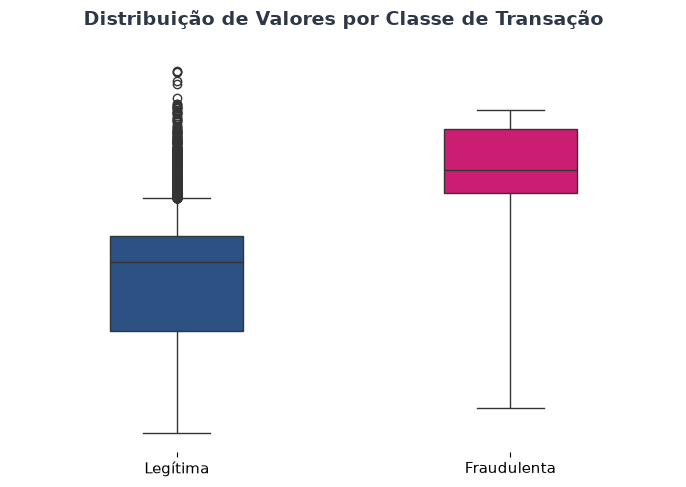

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    x="is_fraud",
    y="amt",
    data=df,
    palette=[SERASA_COLORS["azul"], SERASA_COLORS["pink"]],
    width=0.4,
    ax=ax,
    fliersize=6
)

ax.set_yscale("log")  # Preserva visibilidade de ambas as classes
ax.set_xticklabels(["Legítima", "Fraudulenta"])
ax.set_ylabel("Valor da Transação (R$ - Escala Log)", visible=True)
ax.set_xlabel("")

apply_chart_style(ax, "Distribuição de Valores por Classe de Transação")

plt.tight_layout()
plt.show()

#### Porcentagem exata de fraudes que caem na faixa de outliers das legítimas

In [19]:
# 1. Separa os valores de transações legítimas (Classe 0)
legitimas_amt = df[df["is_fraud"] == 0]["amt"]

# 2. Calcula os quartis e o limite superior de outliers das legítimas
q1 = legitimas_amt.quantile(0.25)
q3 = legitimas_amt.quantile(0.75)
iqr = q3 - q1
limite_superior_outliers = q3 + 1.5 * iqr

# 3. Filtra as fraudes (Classe 1)
fraudes = df[df["is_fraud"] == 1]

# 4. Calcula quantas fraudes estão acima desse limite de valor das legítimas
fraudes_camufladas = fraudes[fraudes["amt"] > limite_superior_outliers]
porcentagem_camuflada = (len(fraudes_camufladas) / len(fraudes)) * 100

print(f"--- ANÁLISE DE CAMUFLAGEM DAS FRAUDES ---\n")
print(f"Limite inicial das compras legítimas: R$ {limite_superior_outliers:.2f}")
print(f"Total de fraudes analisadas: {len(fraudes)}")
print(f"Fraudes que se passam por compras legítimas: {len(fraudes_camufladas)}")
print(f"Porcentagem de fraudes camufladas: {porcentagem_camuflada:.2f}%")

--- ANÁLISE DE CAMUFLAGEM DAS FRAUDES ---

Limite inicial das compras legítimas: R$ 190.12
Total de fraudes analisadas: 1782
Fraudes que se passam por compras legítimas: 1338
Porcentagem de fraudes camufladas: 75.08%


In [20]:
# Padrão temporal por horário do dia
df["hour"] = df["trans_date_trans_time"].dt.hour

temporal_fraud = df.groupby("hour")["is_fraud"].mean().reset_index()
temporal_fraud["taxa_fraude_pct"] = temporal_fraud["is_fraud"] * 100

In [21]:
print("--- TABELA 4: TAXA DE FRAUDE POR HORÁRIO DO DIA (AMOSTRA 00h-05h) ---")
display(temporal_fraud.head(6).style.format({"is_fraud": "{:.2f}", "taxa_fraude_pct": "{:.2f}%"}).hide())

--- TABELA 4: TAXA DE FRAUDE POR HORÁRIO DO DIA (AMOSTRA 00h-05h) ---


hour,is_fraud,taxa_fraude_pct
0,0.29,28.92%
1,0.28,27.68%
2,0.27,26.97%
3,0.26,25.54%
4,0.02,1.69%
5,0.02,2.46%


### Visualização de linha para taxa de fraude por hora

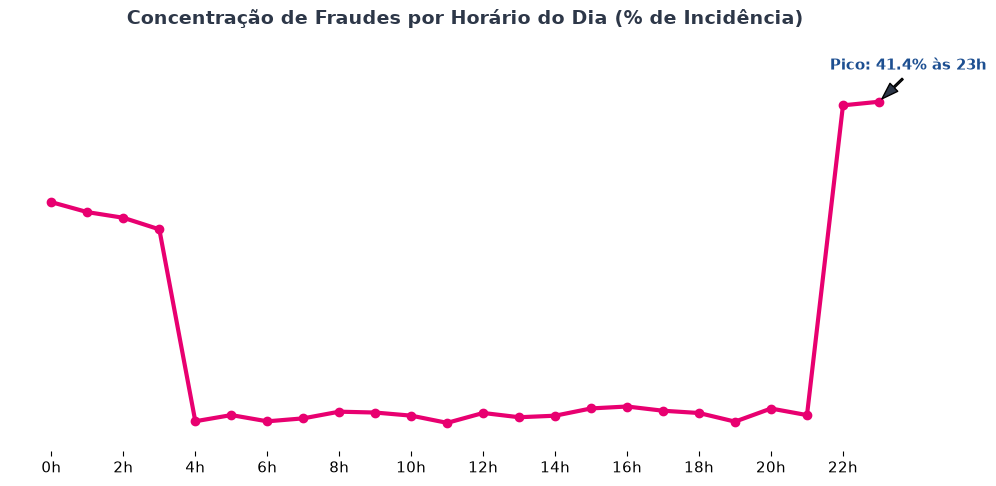

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    temporal_fraud["hour"],
    temporal_fraud["taxa_fraude_pct"],
    color=SERASA_COLORS["pink"],
    linewidth=3,
    marker="o",
    markersize=6,
)

# Destaque para os horários críticos (madrugada)
max_hour = temporal_fraud.loc[temporal_fraud["taxa_fraude_pct"].idxmax()]

ax.annotate(
    f"Pico: {max_hour['taxa_fraude_pct']:.1f}% às {int(max_hour['hour'])}h",
    xy=(max_hour["hour"], max_hour["taxa_fraude_pct"]),
    xytext=(max_hour["hour"] + 3, max_hour["taxa_fraude_pct"] + 4),
    ha="right",
    arrowprops=dict(
        facecolor=SERASA_COLORS["cinza_escuro"],
        shrink=0.1,
        width=1.2,
        headwidth=8
    ),
    fontweight="bold",
    color=SERASA_COLORS["azul"],
)

ax.set_ylim(bottom=-2, top=max_hour["taxa_fraude_pct"] * 1.15)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h}h" for h in range(0, 24, 2)])
ax.yaxis.set_visible(False)

apply_chart_style(ax, "Concentração de Fraudes por Horário do Dia (% de Incidência)")

plt.tight_layout()
plt.show()

## Feature engineering

In [23]:
# Função Haversine para cálculo de distância geográfica
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0  # Raio da Terra em km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

In [24]:
# Feature 1: Distância física em km entre o cliente e o estabelecimento
df["distance_km"] = haversine_distance(
    df["lat"], df["long"], df["merch_lat"], df["merch_long"]
)

In [25]:
# Feature 2: Indicador de transação em horário de risco
df["is_risk_hour"] = df["hour"].apply(lambda h: 1 if (h >= 22 or h <= 3) else 0)

In [26]:
# Feature 3: Idade do titular no momento da transação
df["age"] = ((df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25).astype(int)

In [27]:
# Feature 4: Razão entre o valor da transação e a média da categoria
category_avg = df.groupby("category")["amt"].transform("mean")
df["amt_to_cat_avg_ratio"] = df["amt"] / category_avg

In [28]:
# Tabela explicativa e estatística das novas features
features_summary = (
    df.groupby("is_fraud")[
        ["distance_km", "is_risk_hour", "age", "amt_to_cat_avg_ratio"]
    ]  # <<< adicionado aqui
    .mean()
    .T.reset_index()  # Transpõe para o formato de linhas
    .rename(columns={"index": "Feature", 0: "Média (Legítimas)", 1: "Média (Fraudes)"})
)

# Mapeia a descrição de negócio usando um dicionário
descricoes = {
    "distance_km": "Distância em km entre o portador do cartão e o estabelecimento",
    "is_risk_hour": "Flag binário para transações efetuadas na madrugada (22h às 03h)",
    "age": "Idade do cliente no momento em que realizou a transação",
    "amt_to_cat_avg_ratio": "Razão entre o valor da transação e a média de valor da categoria",  # <<< adicionado aqui
}

features_summary.insert(1, "Descrição de Negócio", features_summary["Feature"].map(descricoes))

In [29]:
def formatar_valores(row, col_name):
    valor = row[col_name]
    # Se a linha atual for a da feature 'age', formata como inteiro puro
    if row["Feature"] == "age":
        return f"{valor:.0f}"
    # Para 'amt_to_cat_avg_ratio', 3 casas decimais (valores costumam ficar perto de 1.0)
    if row["Feature"] == "amt_to_cat_avg_ratio":  # <<< adicionado aqui
        return f"{valor:.3f}"
    # Para as demais features (distância e hora), mantém duas casas decimais
    return f"{valor:.2f}"

features_summary["Média (Legítimas)"] = features_summary.apply(formatar_valores, col_name="Média (Legítimas)", axis=1)
features_summary["Média (Fraudes)"] = features_summary.apply(formatar_valores, col_name="Média (Fraudes)", axis=1)

In [30]:
print("--- TABELA 5: ENGENHARIA DE RECURSOS E COMPARAÇÃO DE COMPORTAMENTO ---")
display(features_summary.round(2).style.hide())

--- TABELA 5: ENGENHARIA DE RECURSOS E COMPARAÇÃO DE COMPORTAMENTO ---


Feature,Descrição de Negócio,Média (Legítimas),Média (Fraudes)
distance_km,Distância em km entre o portador do cartão e o estabelecimento,75.87,75.57
is_risk_hour,Flag binário para transações efetuadas na madrugada (22h às 03h),0.23,0.86
age,Idade do cliente no momento em que realizou a transação,47,50
amt_to_cat_avg_ratio,Razão entre o valor da transação e a média de valor da categoria,0.790,2.482


## Query analítica (pandas estilo SQL)

In [31]:
fraudes = df[df["is_fraud"] == 1]

# Total de transações e total de fraudes por categoria
query_result = (
    df.groupby("category")
    .agg(
        total_transacoes=("is_fraud", "count"),
        total_fraudes=("is_fraud", "sum"),
    ).reset_index()
)

query_result["taxa_fraude_pct"] = (query_result["total_fraudes"] / query_result["total_transacoes"]) * 100

# Valor médio das fraudes por categoria
valor_medio_por_categoria = (
    fraudes.groupby("category")["amt"]
    .mean()
    .reset_index()
    .rename(columns={"amt": "valor_medio_fraude"})
)

query_result = (
    query_result.merge(valor_medio_por_categoria, on="category", how="left")
    .sort_values(by="taxa_fraude_pct", ascending=False)
    .head(5)
)

In [32]:
print("--- TABELA 6: TOP 5 CATEGORIAS DE MAIOR RISCO ---")
display(query_result.style.format({"taxa_fraude_pct": "{:.2f}%", "valor_medio_fraude": "R$ {:.2f}"}).hide())

--- TABELA 6: TOP 5 CATEGORIAS DE MAIOR RISCO ---


category,total_transacoes,total_fraudes,taxa_fraude_pct,valor_medio_fraude
shopping_net,1393,381,27.35%,R$ 1001.13
grocery_pos,1591,433,27.22%,R$ 315.23
misc_net,815,217,26.63%,R$ 797.16
shopping_pos,1347,187,13.88%,R$ 886.33
gas_transport,1424,153,10.74%,R$ 12.65


### Gráfico de Barras do Top 5 Categorias por Taxa de Fraude

In [33]:
# Limpa os underlines e deixa em maiúsculo para o relatório final
query_result["category"] = query_result["category"].str.replace("_", " ").str.title()

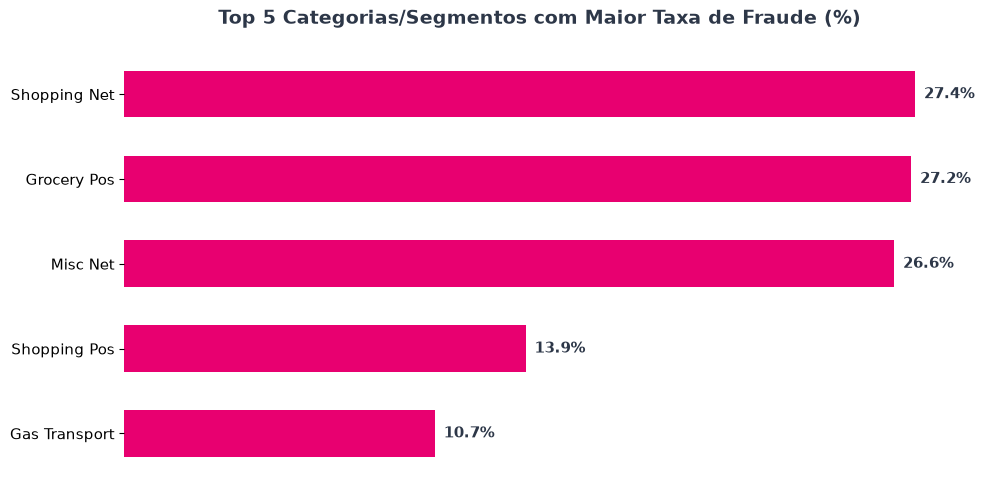

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    query_result["category"],
    query_result["taxa_fraude_pct"],
    color=SERASA_COLORS["pink"],
    height=0.55,
)

ax.invert_yaxis()  # Maior taxa no topo

for bar in bars:
    w = bar.get_width()
    ax.text(
        w + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.1f}%",
        va="center",
        ha="left",
        fontweight="bold",
        color=SERASA_COLORS["cinza_escuro"],
    )

apply_chart_style(ax, "Top 5 Categorias/Segmentos com Maior Taxa de Fraude (%)")

ax.yaxis.set_visible(True)
ax.xaxis.set_visible(False)

plt.tight_layout()
plt.show()